In [1]:
from torch_model import reccurentActor
from torch_learning_utils import train_model
import pandas as pd

In [2]:
model = reccurentActor()
model.set_initial_state('actor_weights.pth')

In [3]:
df = pd.read_csv('wbtc_train_data_expanded.csv')
nav = df['nav'].values
nect_price = df['nect_price'].values
vol_token_price = df['wbtc_price'].values
volatile_part = df['wbtc_frac'].values

nav = nav[::4]
nect_price = nect_price[::4]
vol_token_price = vol_token_price[::4]
volatile_part = volatile_part[::4]

def create_config(top_laverage, bottom_laverage):
    return {
        'nect_price': nect_price,
        'nav': nav,
        'vol_part': volatile_part,
        'vol_token_honey_price': vol_token_price,
        'is_reversed': True,
        'top_leverage': max(top_laverage, bottom_laverage),
        'bottom_leverage': min(top_laverage, bottom_laverage)
    }

In [4]:
configs = [
    create_config(1.8, 2.2),
    create_config(2.3, 2.7),
    create_config(2.8, 3.2),
    create_config(1.8, 2.2),
    create_config(2.3, 2.7),
    create_config(2.8, 3.2),
    create_config(1.8, 2.2)
]

In [5]:
def lr_schedual(frac):
    if frac < 0.7:
        return 5e-4
    else:
        return (1e-4 - 5e-4)/(1 - 0.6)*(frac - 0.6) + 5e-4 
    
def epsilon_schedual(frac):
    if frac < 0.25:
        return 0.05
    else:
        if frac < 0.75:
            return 0.01
        else: 
            return 0.05

def eff_entropy_schedual(frac):
    if frac < 0.5:
        return (0.5 - frac)/0.5*0.02 + 0.001
    else:
        return 0.001

In [6]:
logs = train_model(
    model=model,
    configs=configs,
    n_episodes = 200, 
    lr = lr_schedual,
    ent_coef_alt = 0.005,
    epsilon = epsilon_schedual
)

Training:   0%|          | 1/200 [00:39<2:11:11, 39.55s/it]

Episode: 0 :
mean reward: -0.5897347199228438


Training:   6%|▌         | 11/200 [04:12<1:06:14, 21.03s/it]

Episode: 10 :
mean reward: -2.5780730017882285


Training:  10%|█         | 21/200 [07:56<1:07:42, 22.70s/it]

...

Training:  90%|█████████ | 181/200 [1:05:58<06:49, 21.56s/it]

Episode: 180 :
mean reward: 0.1791279900836938


Training:  96%|█████████▌| 191/200 [1:09:39<03:15, 21.77s/it]

Episode: 190 :
mean reward: 0.20946203118034676


Training: 100%|██████████| 200/200 [1:12:55<00:00, 21.88s/it]


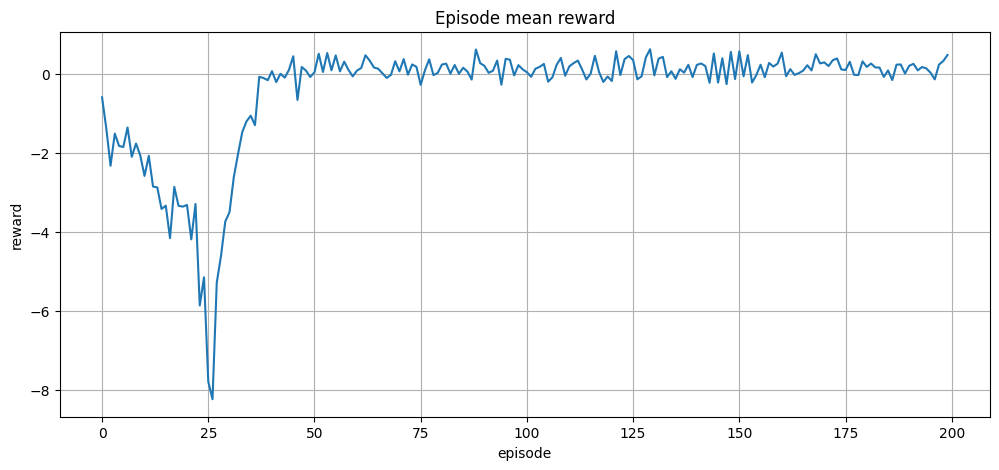

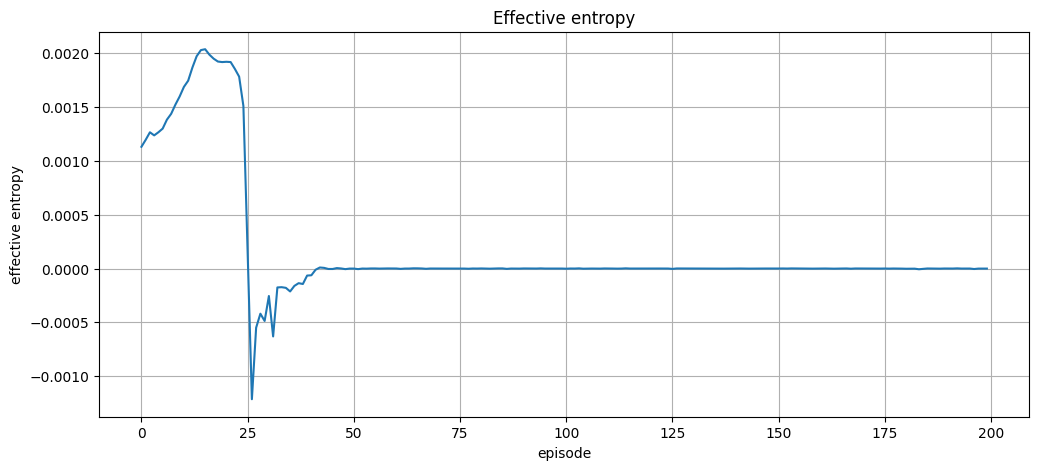

In [7]:
from utils import plot

plot(
    None,
    logs['mean_reward'],
    'episode',
    'reward',
    'Episode mean reward'
)

plot(
    None,
    logs['effective_entropy_loss'],
    'episode',
    'effective entropy',
    'Effective entropy'
)

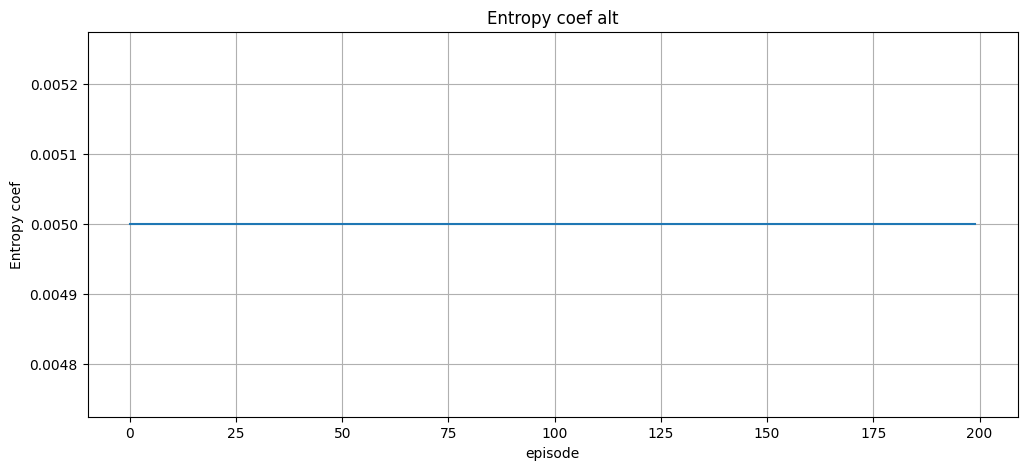

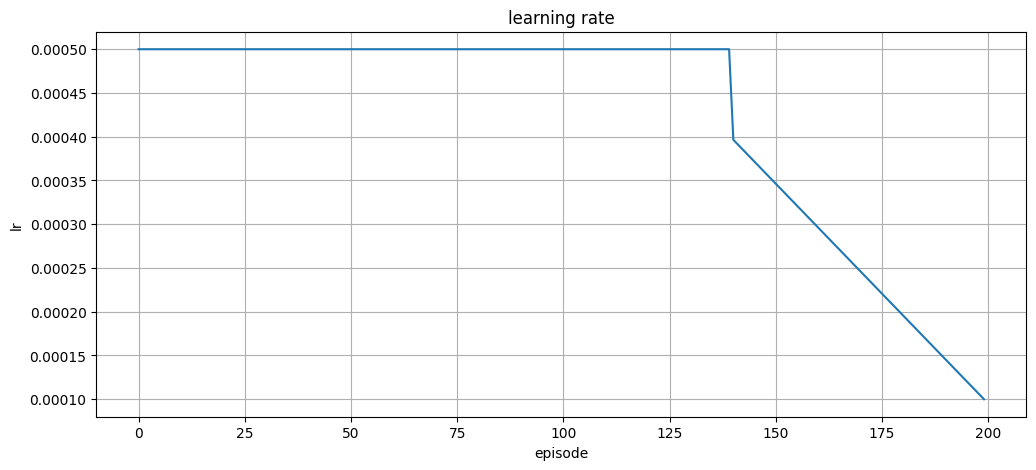

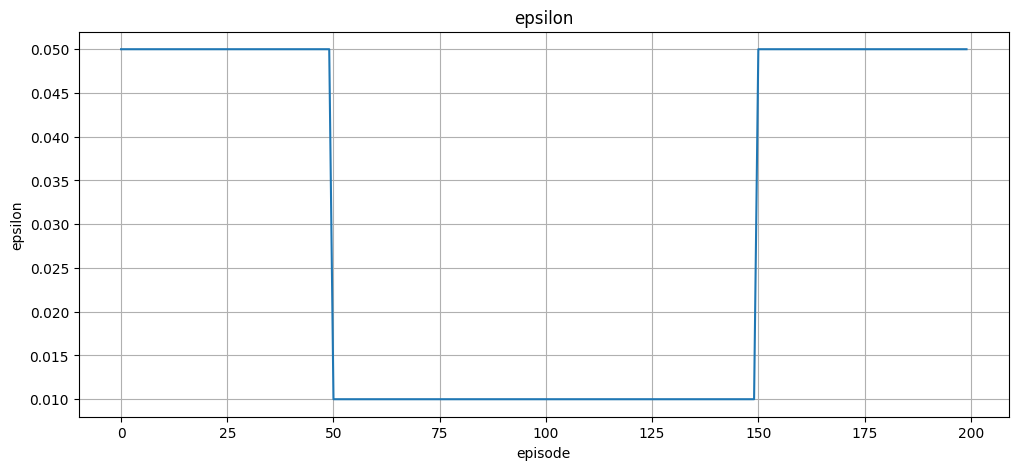

In [8]:
plot(
    None,
    logs['ent_coef_alt'],
    'episode',
    'Entropy coef',
    'Entropy coef alt'
)

plot(
    None,
    logs['learning_rate'],
    'episode',
    'lr',
    'learning rate'
)

plot(
    None,
    logs['epsilon'],
    'episode',
    'epsilon',
    'epsilon'
)